<a href="https://colab.research.google.com/github/Ash3rC/Works/blob/main/Horseshoe_Lake.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from shapely.geometry import Point
import warnings
import matplotlib.dates as mdates
from matplotlib.lines import Line2D
import seaborn as sns
import matplotlib.ticker as mticker
import sklearn
sns.set_theme(style='whitegrid', font_scale=0.8)
warnings.filterwarnings('ignore')

# ML
import xgboost as xgb
from xgboost import XGBRegressor
from xgboost import plot_importance
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import shap

# Classification

from xgboost import XGBClassifier
from sklearn.metrics import classification_report
from sklearn.metrics import roc_curve, roc_auc_score

#file saves
from google.colab import files

#versions
print(gpd.__version__)
print(pd.__version__)
print(np.__version__)
print(shap.__version__)
print(sns.__version__)
print(xgb.__version__)
print(sklearn.__version__)

1.1.4
2.2.2
2.0.2
0.52.0
0.13.2
3.3.0
1.6.1


In [ ]:
# hsl = pd.read_csv('SL_Lake_ML_Data.csv')

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)
hsl = pd.read_csv('/content/drive/MyDrive/HSL_Lake_ML_Data.csv')
lake_dataset = hsl.to_csv('lake_dataset.csv', index=False)
files.download('lake_dataset.csv')

Mounted at /content/drive


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# hsl

In [ ]:
#parsing and sorting by chronological order for the sake of simplicity
hsl['Date'] = pd.to_datetime(hsl['Date'])
hsl = hsl.sort_values('Date').reset_index(drop=True)

#renaming columns for the sake of clean and consistent code
hsl.columns = [
    'Date', 'NDCI', 'NDTI', 'SDD',
    'NO2', 'SO2', 'O3', 'CO', 'Aerosol_Index',
    'TMax', 'TMin', 'RH', 'Rainfall',
    'Wind_Speed', 'Wind_Gust', 'Wind_Direction',
    'Sunshine_Duration', 'PET', 'Cloud_Cover', 'Soil_Moisture'
]

# Sanity Check ->

In [ ]:
hsl.head()

,Date,NDCI,NDTI,SDD,NO2,SO2,O3,CO,Aerosol_Index,TMax,TMin,RH,Rainfall,Wind_Speed,Wind_Gust,Wind_Direction,Sunshine_Duration,PET,Cloud_Cover,Soil_Moisture
0,2020-01-01,0.104,-0.124,0.444000,38.17900,453.6986,152440.55,31356.380,-1.174,12.4,-1.5,58,0.0,4.35,12.2,197,33698.97,2.11,0,0.388
1,2020-01-04,0.012,-0.010,0.431308,53.67025,365.8385,155050.97,33051.650,-0.397,4.6,-0.9,76,0.0,4.05,13.9,290,15322.09,0.78,51,0.379
2,2020-01-06,0.137,-0.187,0.422846,72.78300,307.2651,137886.00,31437.295,-1.992,8.0,-3.2,66,0.0,2.18,5.9,40,33401.82,1.26,45,0.368
3,2020-01-09,0.019,-0.010,0.410154,69.49100,219.4050,136911.68,37041.980,-0.473,13.2,5.6,62,17.5,6.82,17.6,179,10423.67,2.12,96,0.363
4,2020-01-11,-0.031,-0.003,0.401692,86.64900,160.8316,149594.37,35998.235,-1.759,15.6,-0.3,90,60.5,5.03,22.3,313,3381.30,0.43,100,0.428


In [ ]:
hsl['NDCI'].describe()

,NDCI
count,868.000000
mean,0.104957
std,0.090826
min,-0.039000
25%,0.026000
50%,0.087000
75%,0.167250
max,0.391000


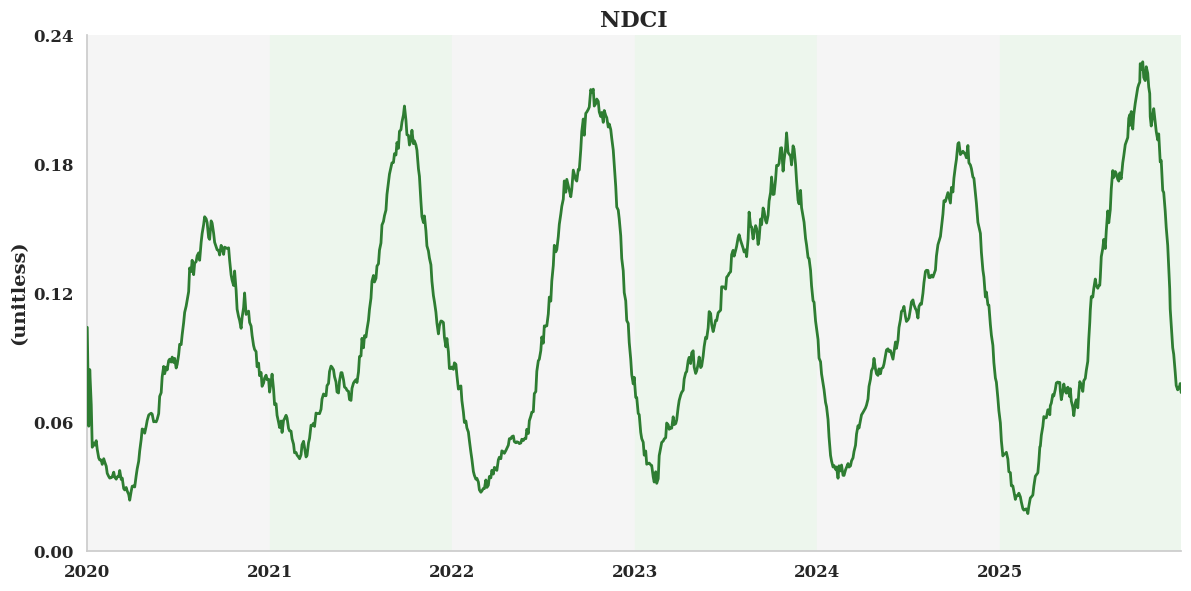

In [ ]:
plt.rcParams['font.family'] = 'serif'

fig, ax = plt.subplots(figsize=(12, 6))
rolling = hsl['NDCI'].rolling(window=27, min_periods=1).mean()

# alternating year bands (gray even / green odd)
yr0, yr1 = hsl['Date'].dt.year.min(), hsl['Date'].dt.year.max()
for yr in range(yr0, yr1 + 1):
    ax.axvspan(pd.Timestamp(f'{yr}-01-01'), pd.Timestamp(f'{yr+1}-01-01'),
               color='#F5F5F5' if yr % 2 == 0 else '#EDF6ED', zorder=0)

ax.plot(hsl['Date'], rolling, color='#2E7D32', linewidth=2.0, zorder=3)

ax.set_title('NDCI', fontsize=16, fontweight='bold')
ax.set_ylabel('(unitless)', fontsize=14, fontweight='bold')
ax.set_ylim(0, 0.24)
ax.set_yticks(np.arange(0, 0.241, 0.06))

ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.set_xlim(hsl['Date'].min(), hsl['Date'].max())

ax.tick_params(axis='both', labelsize=12)
for lbl in ax.get_xticklabels() + ax.get_yticklabels():
    lbl.set_fontweight('bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(False)

plt.tight_layout()
plt.savefig('ndci_timeseries_original.png', dpi=300, bbox_inches='tight')
plt.show()

From this time series we applied a rolling window of 27 days to visualize the trend more easily. We chose a rolling window of 27 due to the large range of data that we were given. Since each observation is recorded per 3-4 days from the Sentinel Satelite, we chose a window that roughly reflected a month as to focus more on trend rather than extreme detail while also not diminishing the natural quality of our time series.

        Date   NDCI   NDTI  SDD_mean_m_Value  NO2_column_scaled_x1e6  \
0 2020-01-01  0.104 -0.124          0.444000                38.17900   
1 2020-01-04  0.012 -0.010          0.431308                53.67025   
2 2020-01-06  0.137 -0.187          0.422846                72.78300   
3 2020-01-09  0.019 -0.010          0.410154                69.49100   
4 2020-01-11 -0.031 -0.003          0.401692                86.64900   

   SO2_column_scaled_x1e6  O3_column_scaled_x1e6  CO_column_scaled_x1e6  \
0                453.6986              152440.55              31356.380   
1                365.8385              155050.97              33051.650   
2                307.2651              137886.00              31437.295   
3                219.4050              136911.68              37041.980   
4                160.8316              149594.37              35998.235   

   Aerosol_Index  TMax (C)  TMin (C)  Relative_Humidity (%)  Rainfall (mm)  \
0         -1.174      12.4      -1.5  

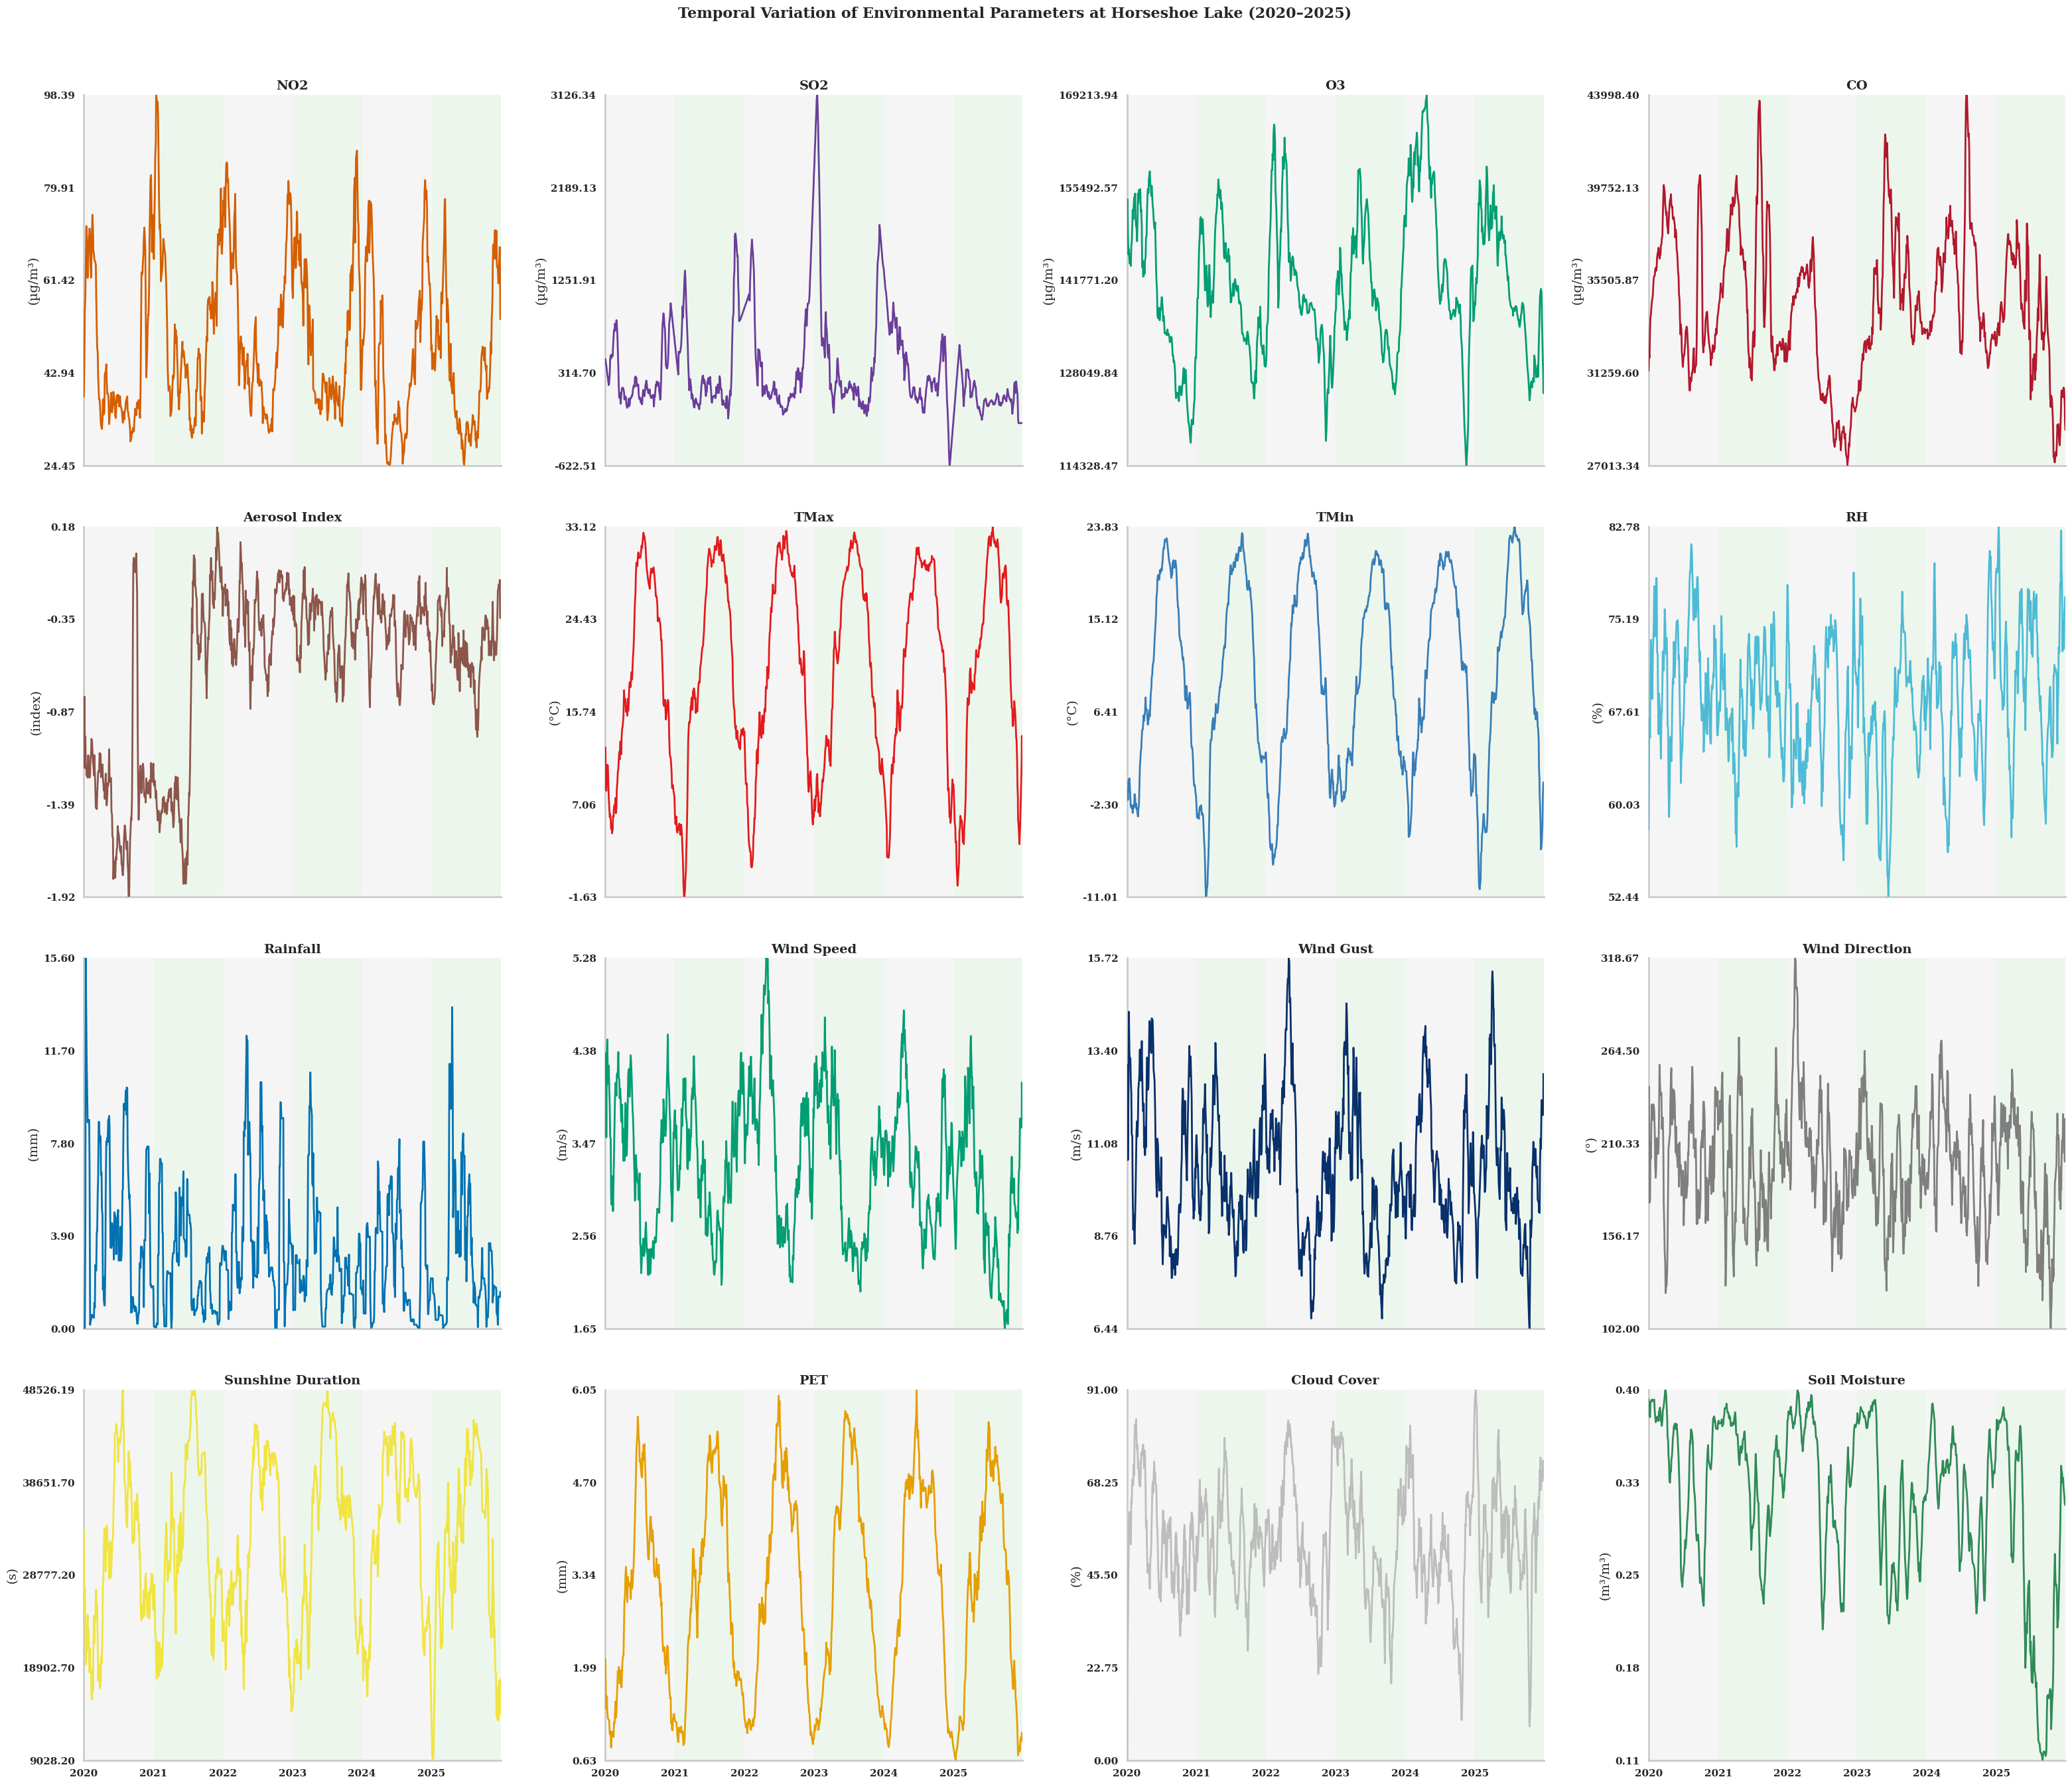

In [ ]:
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.size'] = 11
print(hsl.head())
replacement_dict = {
    'NO2_column_scaled_x1e6': 'NO2',
    'SO2_column_scaled_x1e6': 'SO2',
    'O3_column_scaled_x1e6': 'O3',
    'CO_column_scaled_x1e6': 'CO', 'Aerosol_Index': 'Aerosol Index',
    'TMax (C)': 'TMax', 'TMin (C)': 'TMin', 'Relative_Humidity (%)': 'RH', 'Rainfall (mm)': 'Rainfall',
    'Mean_Wind_Speed (m/s)': 'Wind Speed', 'Maximum_Wind_Gust (m/s)': 'Wind Gust', 'Dominant_Wind_Direction ()': 'Wind Direction', 'Sunshine_Duration (s)': 'Sunshine Duration',
    'Potential_Evapotranspiration (mm)': 'PET', 'Cloud_Cover (%)': 'Cloud Cover', 'soil_moisture_0_to_7cm (m_/m_)': 'Soil Moisture'
}
features = ['NO2_column_scaled_x1e6',
       'SO2_column_scaled_x1e6', 'O3_column_scaled_x1e6',
       'CO_column_scaled_x1e6', 'Aerosol_Index', 'TMax (C)', 'TMin (C)',
       'Relative_Humidity (%)', 'Rainfall (mm)', 'Mean_Wind_Speed (m/s)',
       'Maximum_Wind_Gust (m/s)', 'Dominant_Wind_Direction ()',
       'Sunshine_Duration (s)', 'Potential_Evapotranspiration (mm)',
       'Cloud_Cover (%)', 'soil_moisture_0_to_7cm (m_/m_)']
colors = {
    'NO2_column_scaled_x1e6': '#D55E00', 'SO2_column_scaled_x1e6': '#6A3D9A', 'O3_column_scaled_x1e6': '#009E73', 'CO_column_scaled_x1e6': '#B2182B',
    'Aerosol_Index': '#8C564B', 'TMax (C)': '#E41A1C', 'TMin (C)': '#377EB8', 'Relative_Humidity (%)': '#4DBBD5',
    'Rainfall (mm)': '#0072B2', 'Mean_Wind_Speed (m/s)': '#009E73', 'Maximum_Wind_Gust (m/s)': '#08306B', 'Dominant_Wind_Direction ()': '#7F7F7F',
    'Sunshine_Duration (s)': '#F0E442', 'Potential_Evapotranspiration (mm)': '#E69F00', 'Cloud_Cover (%)': '#BDBDBD', 'soil_moisture_0_to_7cm (m_/m_)': '#2E8B57'
}
units = {
    'NO2_column_scaled_x1e6':'µg/m³','SO2_column_scaled_x1e6':'µg/m³','O3_column_scaled_x1e6':'µg/m³','CO_column_scaled_x1e6':'µg/m³','Aerosol_Index':'index',
    'TMax (C)':'°C','TMin (C)':'°C','Relative_Humidity (%)':'%','Rainfall (mm)':'mm','Mean_Wind_Speed (m/s)':'m/s','Maximum_Wind_Gust (m/s)':'m/s',
    'Dominant_Wind_Direction ()':'°','Sunshine_Duration (s)':'s','Potential_Evapotranspiration (mm)':'mm','Cloud_Cover (%)':'%','soil_moisture_0_to_7cm (m_/m_)':'m³/m³'}

hsl['Date'] = pd.to_datetime(hsl['Date'])
print(type(hsl['Date']))
yr0, yr1 = hsl['Date'].dt.year.min(), hsl['Date'].dt.year.max()
fig, axes = plt.subplots(4, 4, figsize=(32, 28))
axes = axes.flatten()

for i, feature in enumerate(features):
    ax = axes[i]
    rolling = hsl[feature].rolling(window=9, min_periods=1).mean()

    for yr in range(yr0, yr1 + 1):
        ax.axvspan(pd.Timestamp(f'{yr}-01-01'), pd.Timestamp(f'{yr+1}-01-01'),
                   color='#F5F5F5' if yr % 2 == 0 else '#EDF6ED', zorder=0)

    ax.plot(hsl['Date'], rolling, color=colors[feature], linewidth=2.0, zorder=3)

    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.set_xlim(hsl['Date'].min(), hsl['Date'].max())

    ax.set_ylabel(f"({units[feature]})", fontsize=14)
    ax.set_title(feature.replace('_', ' '), fontsize=14, fontweight='bold')

    # 5 evenly spaced ticks across the data range (his style)
    dmin, dmax = rolling.min(), rolling.max()
    ax.set_ylim(dmin, dmax)
    ax.set_yticks(np.linspace(dmin, dmax, 5))
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))

    ax.tick_params(axis='both', labelsize=11, width=1.5)
    for lbl in ax.get_xticklabels() + ax.get_yticklabels():
        lbl.set_fontweight('bold')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    for s in ['left', 'bottom']:
        ax.spines[s].set_linewidth(2)
    ax.grid(False)
    ax.set_facecolor('white')
    ax.set_title( replacement_dict[feature], fontsize=14, fontweight='bold')
for ax in axes[:-4]:
    ax.tick_params(axis='x', labelbottom=False)

fig.patch.set_facecolor('white')
plt.suptitle('Temporal Variation of Environmental Parameters at Horseshoe Lake (2020–2025)',
             fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout(rect=[0.02, 0.02, 1, 0.96], h_pad=4.0, w_pad=2.0)
plt.savefig('16_parameters.png', dpi=300, bbox_inches='tight')
plt.show()

Generated a 4x4 multi time series of the various parameters that we chose to focus on with their relation to NDCI concentration. The multi time series allows us to identify patterns in the elements throughout the years.

In [ ]:
hsl_adjusted = hsl.drop(columns=['Date','NDCI','NDTI','SDD'])
# hsl_adjusted

In [ ]:
print(hsl_adjusted.columns.tolist())

['NO2', 'SO2', 'O3', 'CO', 'Aerosol_Index', 'TMax', 'TMin', 'RH', 'Rainfall', 'Wind_Speed', 'Wind_Gust', 'Wind_Direction', 'Sunshine_Duration', 'PET', 'Cloud_Cover', 'Soil_Moisture']


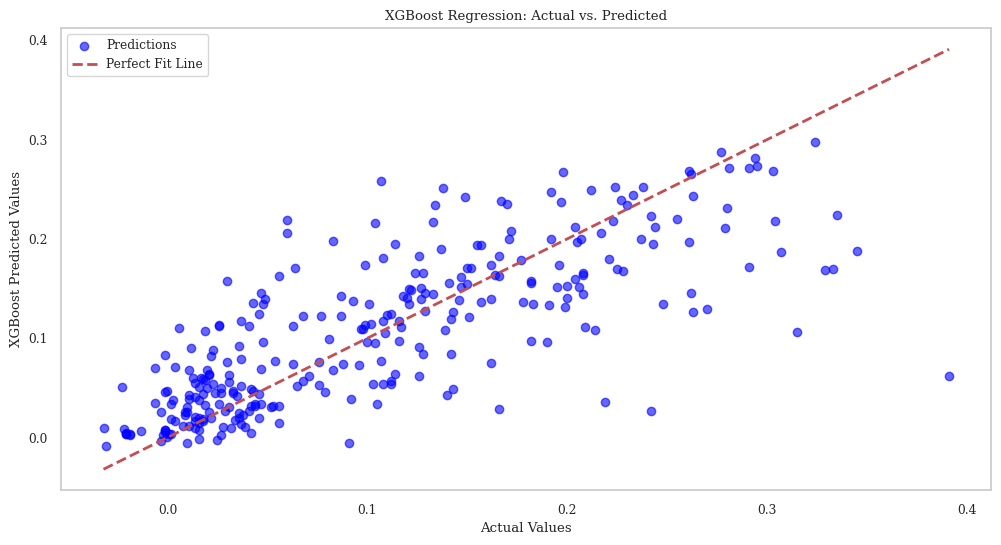

In [ ]:
x =  hsl_adjusted
y = hsl['NDCI']
train = hsl[hsl['Date'] < '2024-01-01']
test = hsl[hsl['Date'] >= '2024-01-01']

x_train = train.drop(columns=['Date','NDCI','NDTI','SDD'])
y_train = train['NDCI']
x_test = test.drop(columns=['Date','NDCI','NDTI','SDD'])
y_test = test['NDCI']

model = XGBRegressor(n_estimators=100, learning_rate=.1, random_state=42)
model.fit(x_train, y_train)
predictions = model.predict(x_test)

results = pd.DataFrame({
    'Date': test['Date'].values,
    'Actual_NDCI': y_test.values,
    'Predicted_NDCI': predictions
})
y_pred = model.predict(x_test)

# results.style.format({
#     'Actual_NDCI': '{:.4f}',
#     'Predicted_NDCI': '{:.4f}'
# })
fig, ax = plt.subplots(figsize=(12, 6))
ax.scatter(y_test, y_pred, color='blue', alpha=0.6, label='Predictions')
ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Fit Line')
ax.set_xlabel('Actual Values')
ax.grid(False)
ax.set_ylabel('XGBoost Predicted Values')
ax.set_title('XGBoost Regression: Actual vs. Predicted')
ax.legend()
plt.show()

Training the model with XGBoost where we manually split the data to keep chronological order with test data being more recent data and train data being older data.

In [ ]:
#Reference

# # visualization of the model performance

# plt.figure(figsize=(14, 5))
# plt.plot(results['Date'], results['Actual_NDCI'], label='Actual', color='steelblue', linewidth=1.2)
# plt.plot(results['Date'], results['Predicted_NDCI'], label='Predicted', color='orange', linewidth=1.2, linestyle='--')
# plt.title('Actual vs Predicted NDCI (2024–2025)')
# plt.xlabel('Date')
# plt.ylabel('NDCI')
# plt.legend()
# plt.tight_layout()
# plt.show()

In [ ]:
# evals
rmse = np.sqrt(mean_squared_error(y_test, predictions))
r2 = r2_score(y_test, predictions)
print(f"RMSE: {rmse}")
print(f"R2: {r2}")

RMSE: 0.06010337610234583
R2: 0.5826170062322606


RMSE is rather high and R2 is rather low, should look into that

In [ ]:
# #creating an Error column in our results to tract residual
results['Error'] = results['Actual_NDCI'] - results['Predicted_NDCI']

In [ ]:
#This cell is just for reference

# fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# #scatter plot
# axes[0].scatter(results['Actual_NDCI'], results['Predicted_NDCI'], alpha=.5, color='steelblue', edgecolors='white', linewidth=.5)

# #Perfect line for reference
# min_val = results['Actual_NDCI'].min()
# max_val = results['Actual_NDCI'].max()
# axes[0].plot([min_val, max_val], [min_val, max_val],
#              color='red', linestyle='--', linewidth=1.2, label='Perfect prediction')

# axes[0].set_xlabel('Actual NDCI')
# axes[0].set_ylabel('Predicted NDCI')
# axes[0].set_title('Actual vs Predicted NDCI')
# axes[0].legend()

# #Resid over time
# axes[1].plot(results['Date'], results['Error'],
#              color='steelblue', linewidth=.8)
# axes[1].axhline(0, color='red', linestyle='--', linewidth=1.2)
# axes[1].set_title('Prediction Error Over Time')
# axes[1].set_xlabel('Date')
# axes[1].set_ylabel('Actual - Predicted')

# plt.tight_layout()
# plt.show

#large negative spikes before the half point and a severe negative spike at the end period
#overprediciton in the earlier parts

In [ ]:
# from sklearn.model_selection import TimeSeriesSplit
# tscv = TimeSeriesSplit(n_splits=5)
# scores = cross_val_score(model, x_train, y_train, cv=tscv, scoring='r2')
# print(scores)
# print("Mean R^2 = ", scores.mean())
# print("Standard Deviation = ", scores.std())

In [ ]:
# #Creating a plot of the residuals
# residuals = y_test - predictions

# plt.scatter(predictions, residuals)
# plt.axhline(0, color='black')
# plt.xlabel("Predicted")
# plt.ylabel("Residual")
# plt.show()

<class 'function'>
<function xlabel at 0x7c2b7f6d5300>


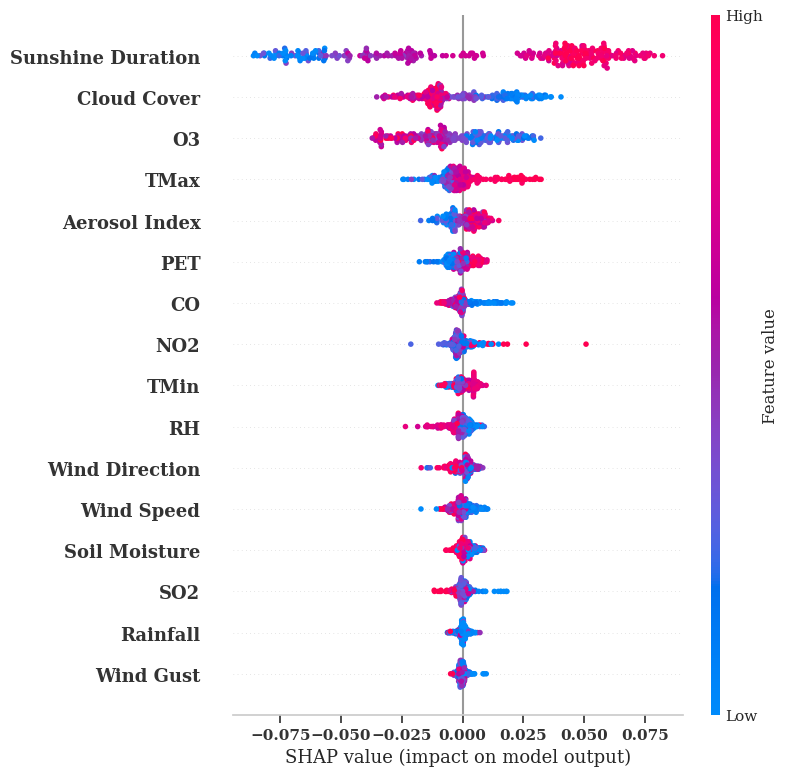

In [ ]:
plt.rcParams['font.family'] = 'serif'
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(x_test)
print(type(plt.xlabel))
print(plt.xlabel)
x_test_display = x_test.copy()
x_test_display.columns = [col.replace('_', ' ') for col in x_test_display.columns]

shap.summary_plot(shap_values, x_test_display, show=False)

ax = plt.gca()
ax.set_facecolor('white')
ax.grid(False)

for label in ax.get_yticklabels():
    label.set_fontweight('bold')
for label in ax.get_xticklabels():
    label.set_fontweight('bold')

plt.gcf().set_facecolor('white')
plt.savefig('shap_summary.png', dpi=300, bbox_inches='tight')
plt.show()

Generated a SHAP summary plot to identfiy key impactors. Noticed that there are 4 main impactors to NDCI concentration

In [ ]:
#For reference

# shap.dependence_plot(
#     'Sunshine_Duration',
#     shap_values,
#     x_test,
#     interaction_index = 'TMax'
# )
# plt.scatter(x_test['Sunshine_Duration'], predictions)
# plt.xlabel('Sunshine Duration')
# plt.ylabel('Predicted NDCI')
# plt.title('Sunshine Duration vs Predicted NDCI')
# plt.show()

In [ ]:
#For reference

# shap.dependence_plot(
#     'Cloud_Cover',
#     shap_values,
#     x_test,
#     interaction_index = 'RH'
# )
# plt.scatter(x_test['Cloud_Cover'], predictions)
# plt.xlabel('Cloud Cover')
# plt.ylabel('Predicted NDCI')
# plt.title('Cloud Cover vs Predicted NDCI')
# plt.show()

In [ ]:
explanation = shap.Explanation(
    values=shap_values,
    data=x_test.values,
    feature_names=x_test.columns.tolist()
)

#shap.plots.bar(explanation)

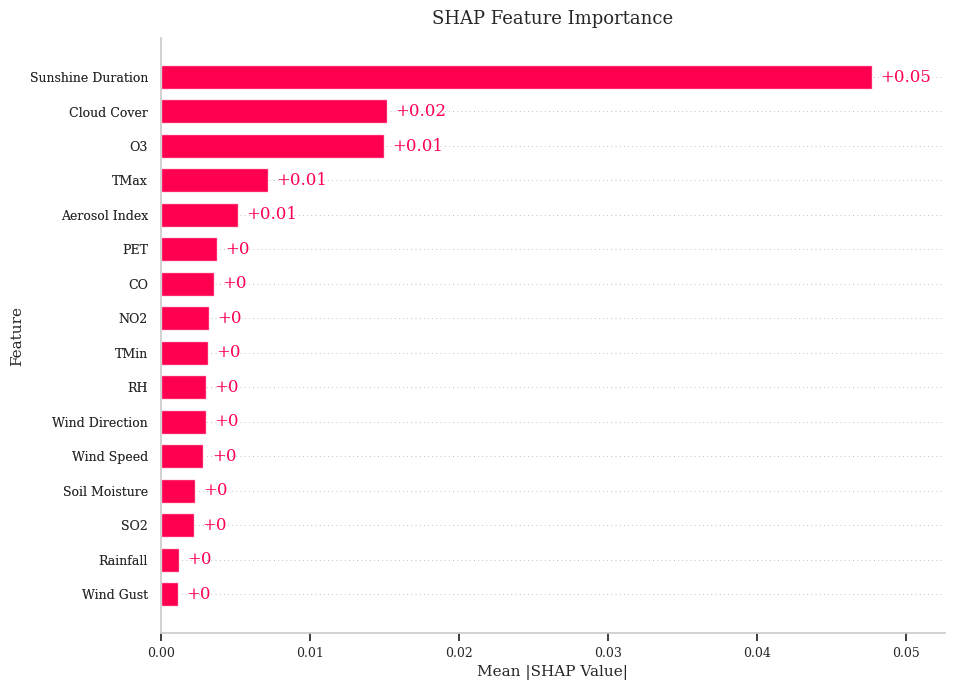

In [ ]:
shap.plots.bar(explanation, max_display=16, show=False)
fig = plt.gcf()
ax = plt.gca()
ax.set_yticklabels([label.get_text().replace('_', ' ') for label in ax.get_yticklabels()])
fig.set_size_inches(10, 8)
plt.title("SHAP Feature Importance", fontsize=13, pad=10)
plt.grid(False)
plt.xlabel('Mean |SHAP Value|', fontsize=11)
plt.ylabel('Feature', fontsize=11)
ax.tick_params(axis='both', labelsize=9)
plt.tight_layout()
plt.subplots_adjust(left=.2)
plt.subplots_adjust(bottom=.2)
plt.savefig('shap_bar.png', dpi=300, bbox_inches='tight')
# files.download('shap_bar.png')
plt.show()

Generated a bar plot to better visualize the influence of various parameters to the regression model. Noticed severe influence with Sunshine Duration and moderate influence of Cloud Cover and O3. This checks out as more sunshine means more photosynthesis which promotes more Algae growth.

In [ ]:
#Classifier

hsl['Bloom'] = np.where(hsl['NDCI'] >= .2, 1, 0)
hsl['Bloom'].value_counts()

,count
Bloom,
0,708
1,160


Developed a classifier column and set a threshold of .2 NDCI. Additionally identified the scale pos weight of our classifier model through value_counts.

In [ ]:
#scaling

cx = hsl
cy = hsl['Bloom']

ctrain = hsl[hsl['Date'] < '2024-01-01']
ctest = hsl[hsl['Date'] >= '2024-01-01']
cx_train = ctrain.drop(columns=[ 'Date','NDCI','NDTI','SDD', 'Bloom'])
cx_train.replace('_', ' ')
cy_train = ctrain['Bloom']
cx_test = ctest.drop(columns=['Date', 'NDCI','NDTI','SDD', 'Bloom'])
cy_test = ctest['Bloom']

cmodel = XGBClassifier(scale_pos_weight=4.42, n_estimators=100, learning_rate=.1, random_state=42)
cmodel.fit(cx_train, cy_train)
cpred = cmodel.predict(cx_test)

trough_dates = ctest.index[cpred == 0]
bloom_dates = ctest.index[cpred == 1]

print(classification_report(cy_test, cpred))

              precision    recall  f1-score   support

           0       0.90      0.88      0.89       236
           1       0.54      0.61      0.57        56

    accuracy                           0.83       292
   macro avg       0.72      0.74      0.73       292
weighted avg       0.83      0.83      0.83       292



Trained and fitted the classifier model with the same manual split but this time we scaled appropiately given the imbalance of our threshold.

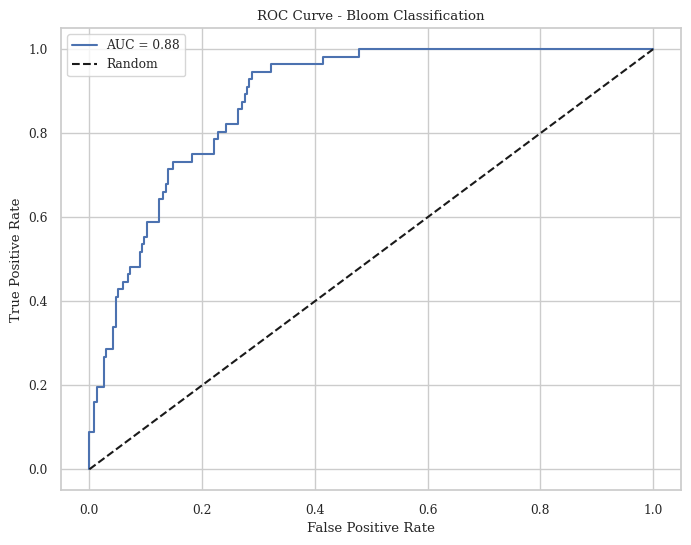

In [ ]:
cprob = cmodel.predict_proba(cx_test)[:, 1]

fpr, tpr, thresholds = roc_curve(cy_test, cprob)
auc = roc_auc_score(cy_test, cprob)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'AUC = {auc:.2f}')
plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Bloom Classification')
plt.legend()
plt.show()

noticed that while our RMSE and R2 for our linear regression model were not favorablem, our classifier model demonstrates relatively good performance. The curve hugs the left corner indiciating that the model is performing accurately.

In [ ]:
cpred_adjusted = (cprob >= .3).astype(int)

print(classification_report(cy_test, cpred_adjusted))

              precision    recall  f1-score   support

           0       0.92      0.86      0.89       236
           1       0.54      0.70      0.61        56

    accuracy                           0.83       292
   macro avg       0.73      0.78      0.75       292
weighted avg       0.85      0.83      0.84       292



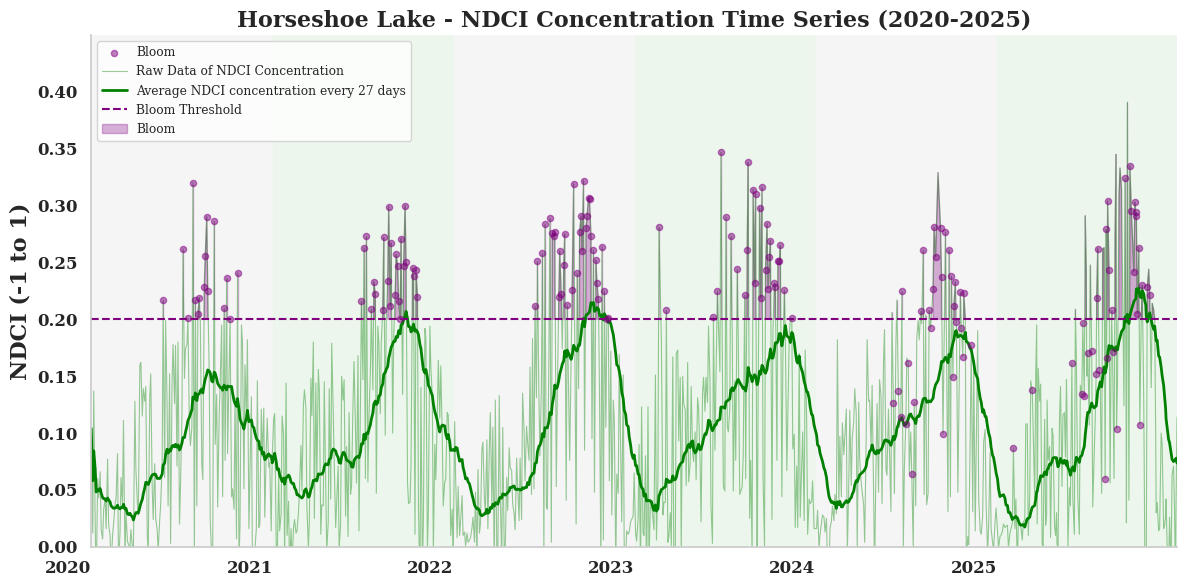

In [ ]:
fig, ax = plt.subplots(figsize=(12,6))
x_all = hsl.drop(columns=['Date','NDCI','NDTI','SDD','Bloom','Prediction'], errors='ignore')
hsl['Prediction'] = cmodel.predict(x_all)
bloom = hsl[hsl['Prediction'] == 1]
ax.scatter(bloom['Date'], bloom['NDCI'], color='purple', s=20, label='Bloom', zorder = 5, alpha=.5)

no_bloom = hsl[hsl['Prediction'] == 0]
rolling = hsl['NDCI'].rolling(window=27, min_periods=1).mean()

# raw data - light background line
ax.plot(hsl['Date'], hsl['NDCI'], color='green', linewidth=.8, alpha=.4, label='Raw Data of NDCI Concentration')

# rolling mean - bold foreground line
ax.plot(hsl['Date'], rolling, color='green', linewidth=2.0, alpha=1.0, label='Average NDCI concentration every 27 days')

ax.set_title('Horseshoe Lake - NDCI Concentration Time Series (2020-2025)', fontweight = 'bold', fontsize=16)
ax.set_ylabel('NDCI (-1 to 1)', fontsize=16, fontweight='bold')
ax.tick_params(axis='both', labelsize=9)
# ax.grid(False)
ax.grid(True, axis='y', color='lightgray', linewidth=0.5, linestyle='--')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(True)
ax.spines['left'].set_visible(True)
yr0, yr1 = hsl['Date'].dt.year.min(), hsl['Date'].dt.year.max()
for yr in range(yr0, yr1 + 1):
    ax.axvspan(pd.Timestamp(f'{yr}-01-01'), pd.Timestamp(f'{yr+1}-01-01'),
               color='#F5F5F5' if yr % 2 == 0 else '#EDF6ED', zorder=0)
ax.xaxis.grid(False)

plt.axhline(y=.2, color='purple', linestyle='--', label='Bloom Threshold')
ax.fill_between(hsl['Date'], hsl['NDCI'], 0.2, where=hsl['NDCI'] >= 0.2, color='purple', alpha=0.3, label='Bloom')
ax.set_ylim(bottom=0, top=hsl['NDCI'].max() * 1.15)

ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1,4,7,10]))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=0, ha='right')
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.set_xlim(hsl['Date'].min(), hsl['Date'].max())
ax.tick_params(axis='both', labelsize=12)
for lbl in ax.get_xticklabels() + ax.get_yticklabels():
    lbl.set_fontweight('bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(False)
plt.legend(loc='upper left')
plt.tight_layout()
plt.savefig('ndci_timeseries.png', dpi=300, bbox_inches='tight')
plt.show()

Generated another time series of our NDCI Concentration however this time we implement our threshold and compare the raw data to the rolling data and the threshold. Additionally we added a bloom indicator to help visualize severe peaks in time.

This time series shows that around mid summer to early autumn, NDCI concentration is highest. Furthermore we can identify that throughout the years there has been an increase of Algae blooms which could be in response to environmental shifts.

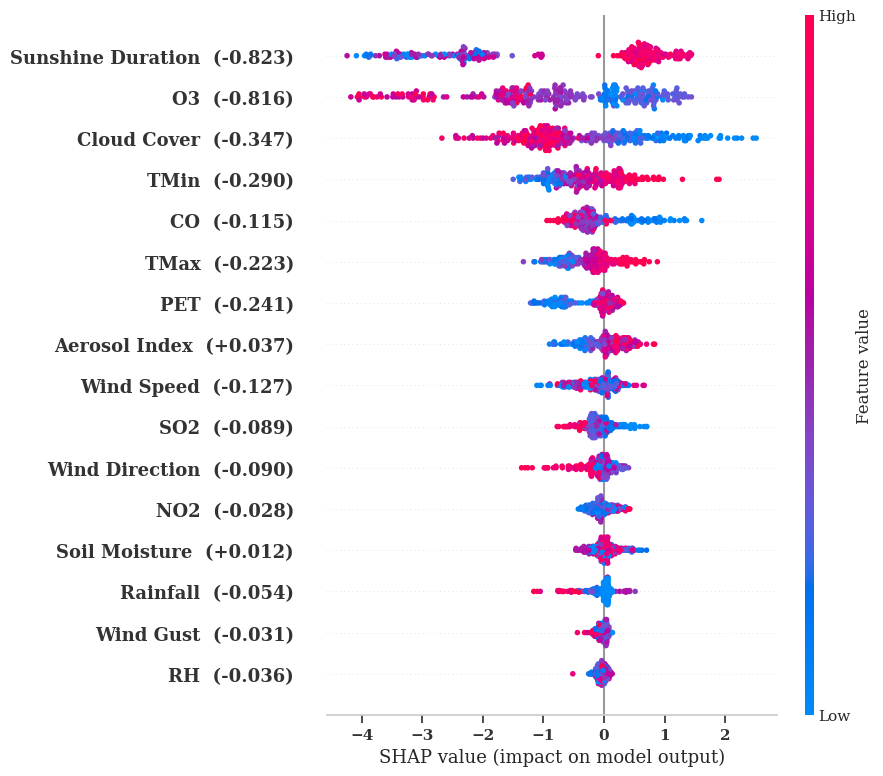

In [ ]:
cexplainer = shap.TreeExplainer(cmodel)
cshap_values = cexplainer.shap_values(cx_test)

cx_test_display = cx_test.copy()
cx_test_display.columns = [col.replace('_', ' ') for col in cx_test_display.columns]

mean_shap_by_feature_c = dict(zip(cx_test_display.columns, cshap_values.mean(axis=0)))

shap.summary_plot(cshap_values, cx_test_display, show=False)

ax = plt.gca()
ax.set_facecolor('white')
ax.grid(False)

new_labels = []
for label in ax.get_yticklabels():
    feature_name = label.get_text()
    mean_val = mean_shap_by_feature_c.get(feature_name, 0)
    sign = '+' if mean_val >= 0 else ''
    new_labels.append(f"{feature_name}  ({sign}{mean_val:.3f})")
ax.set_yticklabels(new_labels, fontweight='bold')

for label in ax.get_xticklabels():
    label.set_fontweight('bold')

plt.gcf().set_facecolor('white')
plt.savefig('cshap_summary.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
cexplanation = shap.Explanation(
    values=cshap_values,
    data=cx_test.values,
    feature_names=cx_test.columns.tolist()
)

#shap.plots.bar(explanation)

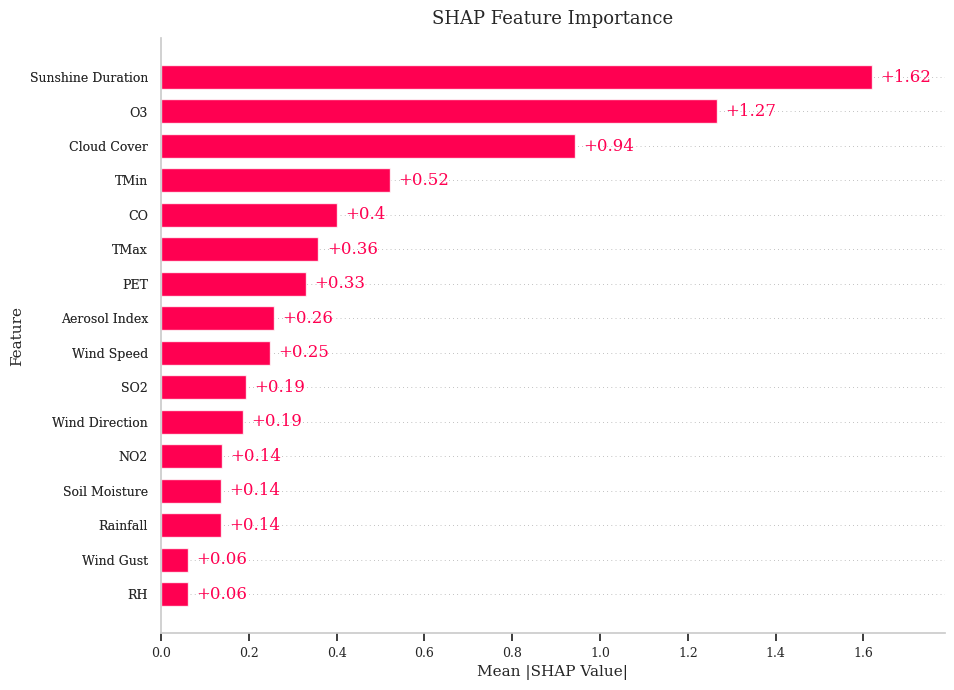

In [ ]:
shap.plots.bar(cexplanation, max_display=16, show=False)
fig = plt.gcf()
ax = plt.gca()
ax.set_yticklabels([label.get_text().replace('_', ' ') for label in ax.get_yticklabels()])
fig.set_size_inches(10, 8)
plt.title("SHAP Feature Importance", fontsize=13, pad=10)
plt.grid(False)
plt.xlabel('Mean |SHAP Value|', fontsize=11)
plt.ylabel('Feature', fontsize=11)
ax.tick_params(axis='both', labelsize=9)
plt.tight_layout()
plt.subplots_adjust(left=.2)
plt.subplots_adjust(bottom=.2)
plt.savefig('cshap_bar.png', dpi=300, bbox_inches='tight')
# files.download('shap_bar.png')
plt.show()

Generated another SHAP bar plot to identify the influence of our parameters in the probability of a bloom event occuring.

In [ ]:
classification_csv = pd.DataFrame({
    'Date': ctest['Date'], 'NDCI-Value': ctest['NDCI'], 'Actual': ['Bloom' if x == 1 else 'No Bloom' for x in cy_test], 'Predicted': ['Bloom' if x == 1 else 'No Bloom' for x in cpred_adjusted]
})
classification_csv.to_csv('classification_results.csv', index=False)

In [ ]:
classification_csv

,Date,NDCI-Value,Actual,Predicted
576,2024-01-03,0.016,No Bloom,No Bloom
577,2024-01-05,0.032,No Bloom,No Bloom
578,2024-01-08,-0.001,No Bloom,No Bloom
579,2024-01-10,0.011,No Bloom,No Bloom
580,2024-01-15,0.028,No Bloom,No Bloom
...,...,...,...,...
863,2025-12-23,0.071,No Bloom,No Bloom
864,2025-12-25,0.033,No Bloom,No Bloom
865,2025-12-27,-0.032,No Bloom,No Bloom
866,2025-12-28,0.033,No Bloom,No Bloom


Statistic confirmation/metrics

In [ ]:
list(x_train.columns)

['NO2',
 'SO2',
 'O3',
 'CO',
 'Aerosol_Index',
 'TMax',
 'TMin',
 'RH',
 'Rainfall',
 'Wind_Speed',
 'Wind_Gust',
 'Wind_Direction',
 'Sunshine_Duration',
 'PET',
 'Cloud_Cover',
 'Soil_Moisture']

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

cprob = cmodel.predict_proba(cx_test)[:, 1]
cpred_adjusted = (cprob >= 0.3).astype(int)

print(classification_report(cy_test, cpred_adjusted))
print(confusion_matrix(cy_test, cpred_adjusted))

              precision    recall  f1-score   support

           0       0.92      0.86      0.89       236
           1       0.54      0.70      0.61        56

    accuracy                           0.83       292
   macro avg       0.73      0.78      0.75       292
weighted avg       0.85      0.83      0.84       292

[[203  33]
 [ 17  39]]


SHAP with full timeline and validation

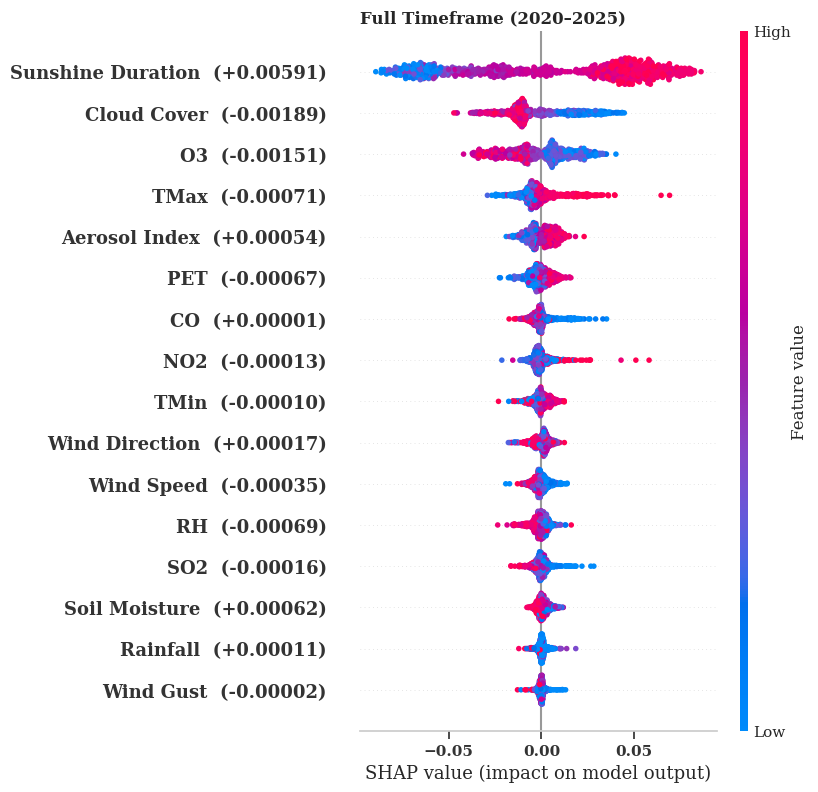

In [ ]:
#REGRESSION
X_full = hsl[x_test.columns]
X_full_display = X_full.copy()

explainer = shap.TreeExplainer(model)
shap_values_full = explainer.shap_values(X_full)

mean_shap = shap_values_full.mean(axis=0)

new_labels = []
for col, val in zip(X_full.columns, mean_shap):
    clean_name = col.replace('_', ' ')
    new_labels.append(f"{clean_name}  ({val:+.5f})")

X_full_display.columns = new_labels

plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values_full, X_full_display, show=False)
ax = plt.gca()
ax.grid(False)
plt.xticks(fontweight='bold')
plt.yticks(fontweight='bold')
plt.title('Full Timeframe (2020–2025)', fontweight='bold', fontsize=12, loc='left')
plt.savefig('shap_regression_full.png', dpi=300, bbox_inches='tight')
# files.download('shap_regression_full.png')
plt.show()

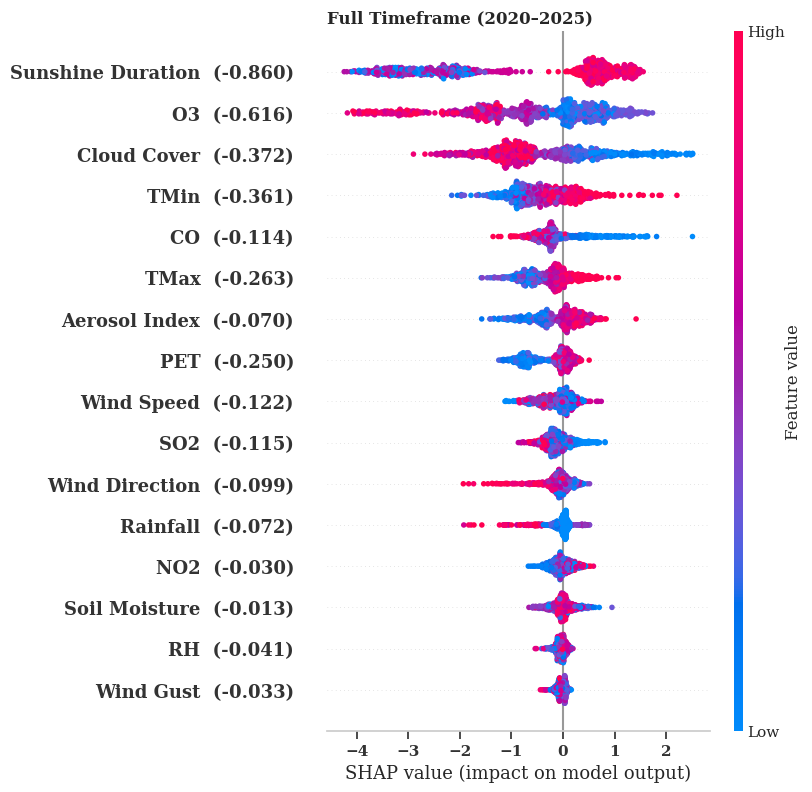

In [ ]:
#CLASSIFICATION
X_cfull = hsl[cx_test.columns]
X_cfull_display = X_cfull.copy()

cexplainer = shap.TreeExplainer(cmodel)
cshap_values_full = cexplainer.shap_values(X_cfull)

cmean_shap = cshap_values_full.mean(axis=0)

cnew_labels = []
for col, val in zip(X_cfull.columns, cmean_shap):
    clean_name = col.replace('_', ' ')
    cnew_labels.append(f"{clean_name}  ({val:+.3f})")

X_cfull_display.columns = cnew_labels

plt.figure(figsize=(10, 8))
shap.summary_plot(cshap_values_full, X_cfull_display, show=False)
ax = plt.gca()
ax.grid(False)
plt.xticks(fontweight='bold')
plt.yticks(fontweight='bold')
plt.title('Full Timeframe (2020–2025)', fontweight='bold', fontsize=12, loc='left')
plt.savefig('shap_classification_full.png', dpi=300, bbox_inches='tight')
# files.download('shap_classification_full.png')
plt.show()

In [ ]:
list(x_test.columns)

['NO2',
 'SO2',
 'O3',
 'CO',
 'Aerosol_Index',
 'TMax',
 'TMin',
 'RH',
 'Rainfall',
 'Wind_Speed',
 'Wind_Gust',
 'Wind_Direction',
 'Sunshine_Duration',
 'PET',
 'Cloud_Cover',
 'Soil_Moisture']

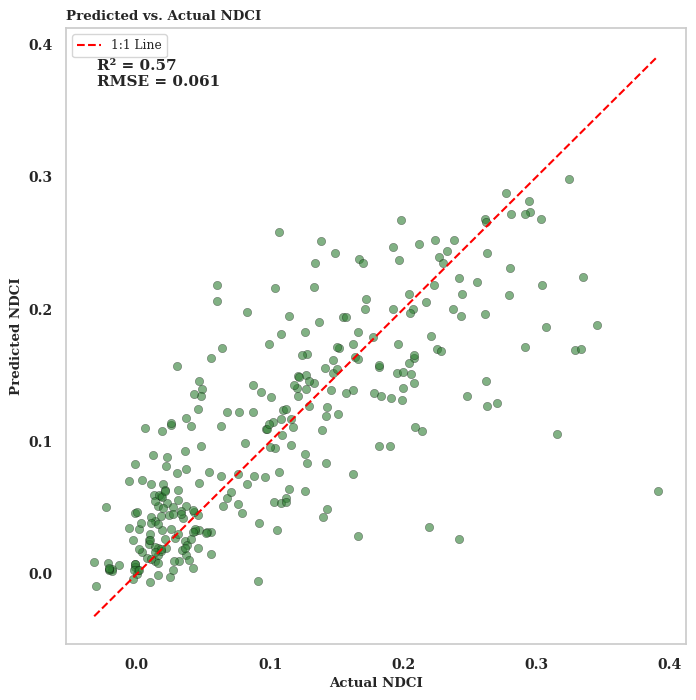

In [ ]:
plt.rcParams['font.family'] = 'serif'

fig, ax = plt.subplots(figsize=(8, 8))

ax.scatter(y_test, predictions, alpha=0.6, color='#2E7D32', edgecolor='black', linewidth=0.3)

# 1:1 reference line
min_val = min(y_test.min(), predictions.min())
max_val = max(y_test.max(), predictions.max())
ax.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=1.5, label='1:1 Line')

ax.set_xlabel('Actual NDCI', fontweight='bold')
ax.set_ylabel('Predicted NDCI', fontweight='bold')
ax.set_title('Predicted vs. Actual NDCI', fontweight='bold', loc='left')
ax.legend()
ax.grid(False)

ax.tick_params(axis='both', labelsize=10)
plt.setp(ax.get_xticklabels(), fontweight='bold')
plt.setp(ax.get_yticklabels(), fontweight='bold')
ax.text(0.05, 0.95, f'R² = 0.57\nRMSE = 0.061', transform=ax.transAxes,
        fontsize=11, fontweight='bold', verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.savefig('regression_validation_scatter.png', dpi=300, bbox_inches='tight')
# files.download('regression_validation_scatter.png')
plt.show()

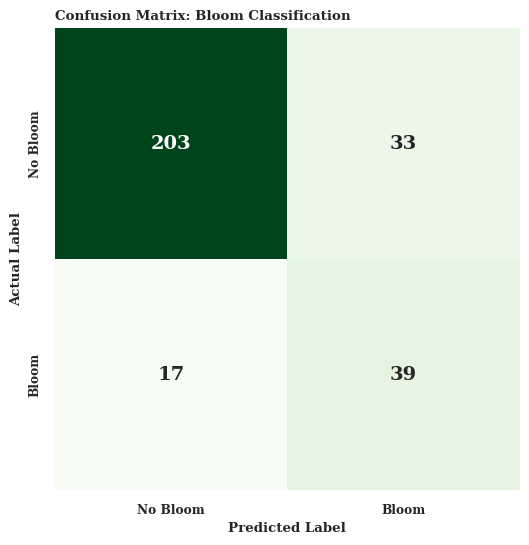

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

plt.rcParams['font.family'] = 'serif'

cm = confusion_matrix(cy_test, cpred_adjusted)

fig, ax = plt.subplots(figsize=(6, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', cbar=False,
            xticklabels=['No Bloom', 'Bloom'], yticklabels=['No Bloom', 'Bloom'],
            annot_kws={'fontweight': 'bold', 'fontsize': 14}, ax=ax)

ax.set_xlabel('Predicted Label', fontweight='bold')
ax.set_ylabel('Actual Label', fontweight='bold')
ax.set_title('Confusion Matrix: Bloom Classification', fontweight='bold', loc='left')

plt.setp(ax.get_xticklabels(), fontweight='bold')
plt.setp(ax.get_yticklabels(), fontweight='bold')

plt.savefig('classification_validation_matrix.png', dpi=300, bbox_inches='tight')
# files.download('classification_validation_matrix.png')
plt.show()

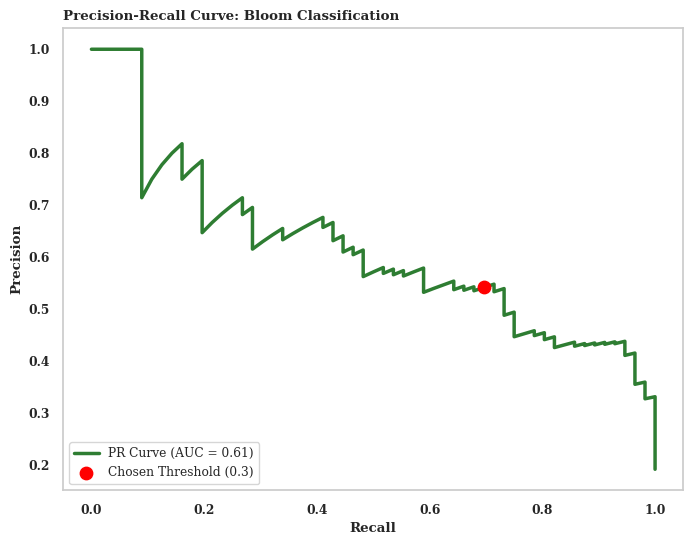

In [ ]:
from sklearn.metrics import precision_recall_curve, auc

plt.rcParams['font.family'] = 'serif'

precision_vals, recall_vals, thresholds = precision_recall_curve(cy_test, cprob)
pr_auc = auc(recall_vals, precision_vals)

fig, ax = plt.subplots(figsize=(8, 6))

ax.plot(recall_vals, precision_vals, color='#2E7D32', linewidth=2.5, label=f'PR Curve (AUC = {pr_auc:.2f})')

# Mark the chosen operating point (decision threshold = 0.3)
idx = (np.abs(thresholds - 0.3)).argmin()
ax.scatter(recall_vals[idx], precision_vals[idx], color='red', s=80, zorder=5,
           label='Chosen Threshold (0.3)')

ax.set_xlabel('Recall', fontweight='bold')
ax.set_ylabel('Precision', fontweight='bold')
ax.set_title('Precision-Recall Curve: Bloom Classification', fontweight='bold', loc='left')
ax.legend(loc='lower left')
ax.grid(False)

plt.setp(ax.get_xticklabels(), fontweight='bold')
plt.setp(ax.get_yticklabels(), fontweight='bold')

plt.savefig('classification_pr_curve.png', dpi=300, bbox_inches='tight')
# files.download('classification_pr_curve.png')
plt.show()

In [ ]:
RANDOM_SEED = 42

bloom_rows = hsl[hsl['Bloom'] == 1]
nonbloom_rows = hsl[hsl['Bloom'] == 0]

print(f"Available bloom observations: {len(bloom_rows)}")
print(f"Available non-bloom observations: {len(nonbloom_rows)}")

n_bloom = min(160, len(bloom_rows))
bloom_sample = bloom_rows.sample(n=n_bloom, random_state=RANDOM_SEED)
nonbloom_sample = nonbloom_rows.sample(n=160, random_state=RANDOM_SEED)

balanced_hsl = pd.concat([bloom_sample, nonbloom_sample]).sort_values('Date').reset_index(drop=True)
print("\nBalanced set total:", balanced_hsl['Bloom'].value_counts().to_dict())

btrain = balanced_hsl[balanced_hsl['Date'] < '2024-01-01']
btest = balanced_hsl[balanced_hsl['Date'] >= '2024-01-01']

print("\nTrain class balance:", btrain['Bloom'].value_counts().to_dict())
print("Test class balance:", btest['Bloom'].value_counts().to_dict())

bcx_train = btrain.drop(columns=['Date','NDCI','NDTI','SDD','Bloom','Prediction'], errors='ignore')
bcy_train = btrain['Bloom']
bcx_test = btest.drop(columns=['Date','NDCI','NDTI','SDD','Bloom','Prediction'], errors='ignore')
bcy_test = btest['Bloom']

from xgboost import XGBClassifier

bcmodel = XGBClassifier(n_estimators=100, learning_rate=.1, random_state=RANDOM_SEED)
bcmodel.fit(bcx_train, bcy_train)

bcprob = bcmodel.predict_proba(bcx_test)[:, 1]
bcpred = (bcprob >= 0.5).astype(int)  # revisit threshold now that classes are balanced

print(classification_report(bcy_test, bcpred))



Available bloom observations: 160
Available non-bloom observations: 708

Balanced set total: {0: 160, 1: 160}

Train class balance: {0: 113, 1: 104}
Test class balance: {1: 56, 0: 47}
              precision    recall  f1-score   support

           0       0.72      0.77      0.74        47
           1       0.79      0.75      0.77        56

    accuracy                           0.76       103
   macro avg       0.76      0.76      0.76       103
weighted avg       0.76      0.76      0.76       103



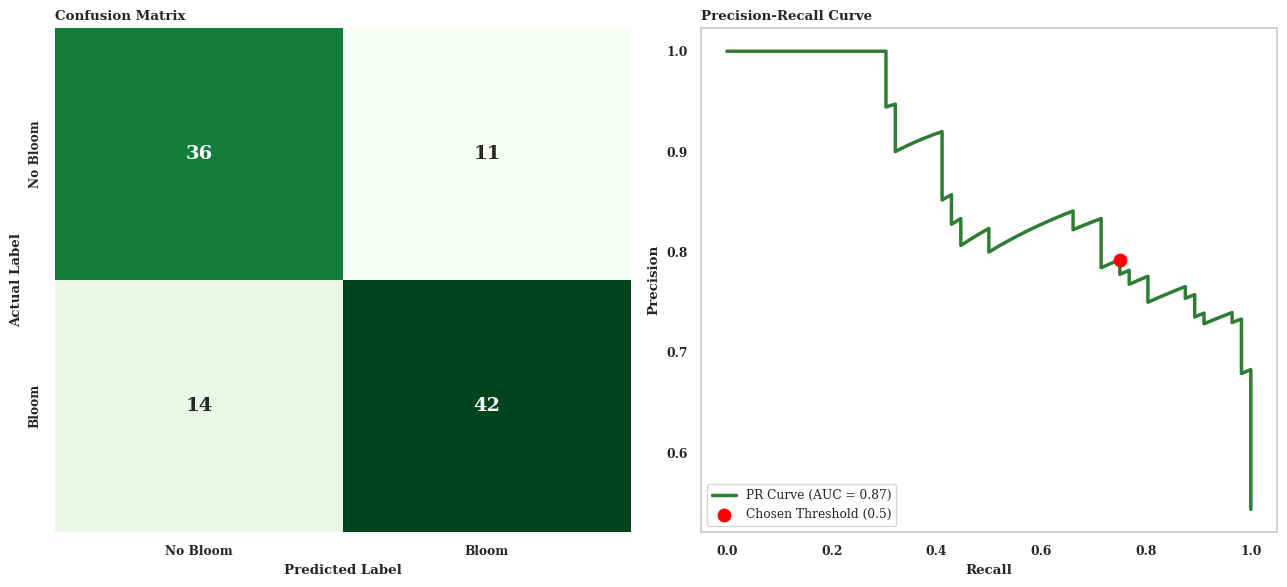

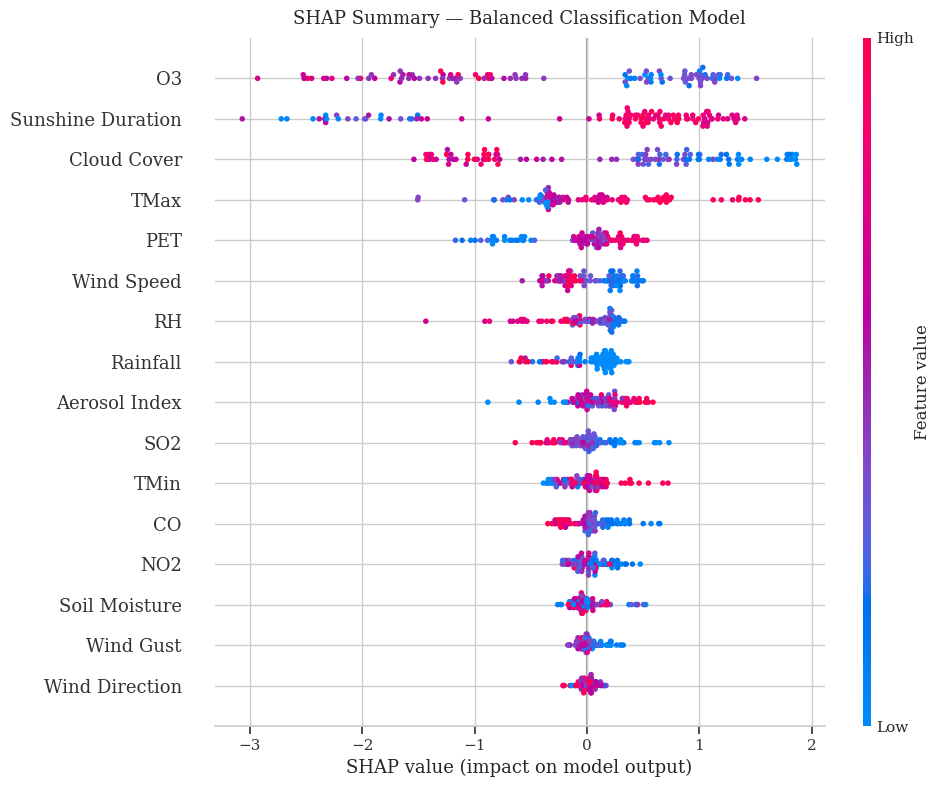

In [ ]:
plt.rcParams['font.family'] = 'serif'

bcm = confusion_matrix(bcy_test, bcpred)
bprecision_vals, brecall_vals, bthresholds = precision_recall_curve(bcy_test, bcprob)
bpr_auc = auc(brecall_vals, bprecision_vals)

fig, axes = plt.subplots(1, 2, figsize=(13, 6))

sns.heatmap(bcm, annot=True, fmt='d', cmap='Greens', cbar=False,
            xticklabels=['No Bloom', 'Bloom'], yticklabels=['No Bloom', 'Bloom'],
            annot_kws={'fontweight': 'bold', 'fontsize': 14}, ax=axes[0])
axes[0].set_xlabel('Predicted Label', fontweight='bold')
axes[0].set_ylabel('Actual Label', fontweight='bold')
axes[0].set_title('Confusion Matrix', fontweight='bold', loc='left')
plt.setp(axes[0].get_xticklabels(), fontweight='bold')
plt.setp(axes[0].get_yticklabels(), fontweight='bold')

axes[1].plot(brecall_vals, bprecision_vals, color='#2E7D32', linewidth=2.5,
             label=f'PR Curve (AUC = {bpr_auc:.2f})')
idx = (np.abs(bthresholds - 0.5)).argmin()
axes[1].scatter(brecall_vals[idx], bprecision_vals[idx], color='red', s=80, zorder=5,
                 label='Chosen Threshold (0.5)')
axes[1].set_xlabel('Recall', fontweight='bold')
axes[1].set_ylabel('Precision', fontweight='bold')
axes[1].set_title('Precision-Recall Curve', fontweight='bold', loc='left')
axes[1].legend(loc='lower left')
axes[1].grid(False)
plt.setp(axes[1].get_xticklabels(), fontweight='bold')
plt.setp(axes[1].get_yticklabels(), fontweight='bold')

plt.tight_layout()
plt.savefig('balanced_classification_validation.png', dpi=300, bbox_inches='tight')
plt.show()

bcexplainer = shap.TreeExplainer(bcmodel)
bcshap_values = bcexplainer.shap_values(bcx_test)

bcx_test_display = bcx_test.copy()
bcx_test_display.columns = [col.replace('_', ' ') for col in bcx_test_display.columns]

plt.rcParams['font.family'] = 'serif'
shap.summary_plot(bcshap_values, bcx_test_display, show=False)

fig = plt.gcf()
ax = plt.gca()
fig.set_size_inches(10, 8)
ax.set_title("SHAP Summary — Balanced Classification Model", fontsize=13, pad=10)
plt.tight_layout()
plt.savefig('balanced_cshap_summary.png', dpi=300, bbox_inches='tight')
plt.show()